In [43]:
import pandas as pd
import os

import os
import warnings
from abc import ABC, abstractmethod
from typing import Any

import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import welch
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import PredefinedSplit
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

In [26]:
'cwd = os.getcwd()
path = os.path.join(cwd, "dano_tipo_2.parquet")
print(path)

C:\Users\Lenovo\Desktop\UFES\2025-2\Diagnostico_Inteligente_Falhas\jupyter_notebooks\dano_tipo_2.parquet


In [27]:
df = pd.read_parquet(path)

In [28]:
df.head()

,ExperimentID,Velocidade,Peso_Vagao,Modulo_Elasticidade,Irregularidade,Dano_Percentual,NodeID,Time,Accel_X,Accel_Y,Accel_Z
0,0,45,1.0,0.975,1,0.01,10679,0.000000,0.000440,-0.007959,-0.001432
1,0,45,1.0,0.975,1,0.01,10679,0.003906,0.002703,-0.008137,-0.001613
2,0,45,1.0,0.975,1,0.01,10679,0.007812,0.000874,-0.008594,-0.001070
3,0,45,1.0,0.975,1,0.01,10679,0.011719,0.000901,-0.008186,-0.000897
4,0,45,1.0,0.975,1,0.01,10679,0.015625,0.001770,-0.009077,-0.000079


In [29]:
df.tail()

,ExperimentID,Velocidade,Peso_Vagao,Modulo_Elasticidade,Irregularidade,Dano_Percentual,NodeID,Time,Accel_X,Accel_Y,Accel_Z
9866281,269,55,0.95,1.025,1,0.5,10673,7.117188,-0.013547,-0.004142,0.003921
9866282,269,55,0.95,1.025,1,0.5,10673,7.121094,0.014524,-0.004392,0.001451
9866283,269,55,0.95,1.025,1,0.5,10673,7.125000,-0.002970,-0.001812,0.001610
9866284,269,55,0.95,1.025,1,0.5,10673,7.128906,0.005330,-0.001792,-0.001205
9866285,269,55,0.95,1.025,1,0.5,10673,7.132812,0.010691,-0.001070,-0.000873


In [30]:
df_aux = df[df['NodeID'] == 10673]

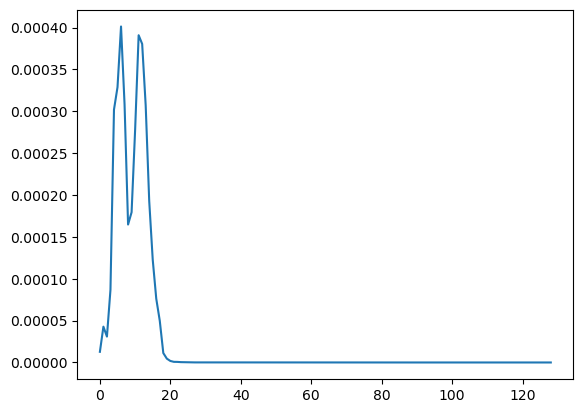

In [31]:
import matplotlib.pyplot as plt
from scipy.signal import welch

x = df_aux['Time']
y = df_aux['Accel_Y']


In [82]:
from scipy.signal import butter, filtfilt

x = df_aux['Time'].values
y = df_aux['Accel_Y'].values

dt = np.mean(np.diff(x))
fs = 256

cutoff_l = 16
cutoff_h = 2


def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

def butter_highpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, data)

def filter_signal(data, cutoff_h = 20, cutoff_l = 2, fs = 256, order = 4):
    nyq = 0.5 * fs
    normal_cutoff_l = cutoff_l / nyq
    normal_cutoff_h = cutoff_h / nyq
    b,a = butter(order, [normal_cutoff_l, normal_cutoff_h], btype = 'bandpass')
    return filtfilt(b, a, data)

def extract_time_features(signal: np.ndarray) -> list[float]:
    """Extract time-domain features from signal.

    Args:
        signal (np.ndarray): 1D acceleration signal.

    Returns:
        list[float]: 10 time-domain features.
    """
    mean = np.mean(signal)
    variance = np.var(signal)
    kurtosis = stats.kurtosis(signal)
    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    peak_to_rms = peak / rms if rms > 0 else 0
    rss = np.sqrt(np.sum(signal**2))
    peak_to_peak = np.ptp(signal)
    minimum = np.min(signal)
    maximum = np.max(signal)
    jerk = np.mean(np.abs(np.diff(signal)))

    return [mean, variance, kurtosis, rms, peak_to_rms, rss, 
            peak_to_peak, minimum, maximum, jerk]

def extract_freq_features(signal: np.ndarray, fs: float = 256.0) -> list[float]:
    """Extract frequency-domain features from signal.

    Args:
        signal (np.ndarray): 1D acceleration signal.
        fs (float): Sampling frequency in Hz.

    Returns:
        list[float]: 5 frequency-domain features.
    """
    freqs, psd = welch(signal, fs)
    psd_norm = psd / np.sum(psd)

    centroid = np.sum(freqs * psd_norm)
    spread = np.sqrt(np.sum(((freqs - centroid)**2) * psd_norm))
    skewness = np.sum(((freqs - centroid)**3) * psd_norm) / (spread**3) if spread > 0 else 0
    kurtosis = np.sum(((freqs - centroid)**4) * psd_norm) / (spread**4) if spread > 0 else 0
    entropy = stats.entropy(psd_norm + 1e-12, base=2) # Not absolutely sure that I should use base 2 here

    return [centroid, spread, skewness, kurtosis, entropy]


original_time_features = extract_time_features(y)
original_freq_features = extract_freq_features(y)

y_filtered2 = butter_lowpass_filter(y,1, fs=256)
filtered_time_features = extract_time_features(y_filtered)
filtered_freq_features = extract_freq_features(y_filtered)

filtered_freq_features2 = extract_freq_features(y_filtered2)

In [83]:
print("Time features")
print(original_time_features)
print(filtered_time_features)

print("Freq features")
print(original_freq_features)
print(filtered_freq_features)

Time features
[4.04308451954129e-06, 0.0036729250106989153, 2.5559677585155294, 0.06060466176001189, 5.205725495063146, 44.86902468629489, 0.5897388576289672, -0.31549123284377245, 0.2742476247851947, 0.00976408357472588]
[-9.344819365539877e-08, 0.0035371417748998853, 2.4472108283297906, 0.05947387472587118, 5.063280805006705, 44.03183972599074, 0.5682805312065344, -0.30113292829887695, 0.2671476029076575, 0.009447576388465566]
Freq features
[9.08660910718266, 4.0095622136707565, 1.7017401272150203, 40.65543405261023, 3.8652934982158276]
[9.117907983310364, 3.6379735171406526, 0.09543474836881075, 1.9748621483804194, 3.7436595407423168]
[1.0166235171082194, 0.5898988908250052, 0.012371623779624006, 2.9571210741832266, 1.2817773193299533]


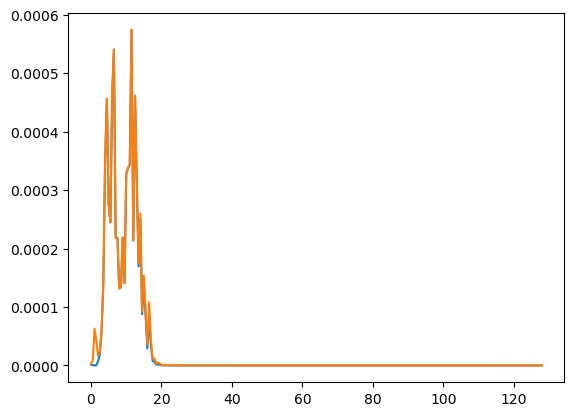

In [88]:
import matplotlib.pyplot as plt
from scipy.signal import welch




x = df_aux['Time']
freqs,psd = welch(y_filtered,fs=256, nperseg = 512)
freqs2,psd2 = welch(y,fs=256, nperseg = 512)
plt.plot(freqs,psd)
plt.plot(freqs2,psd2)
plt.show()